<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-3-Holonomic-Mechanics/Untitled147.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Recovery of a Lagrange Multiplier on S^2**

We consider a great circle on the unit sphere $S^{2}\subset\mathbb{R}^{3}$, parametrized by a smooth curve
$\gamma(t)$ for $t\in[0,1]$. A convenient explicit choice is the equator
$$
\gamma(t)=\big(\cos(\omega t),\,\sin(\omega t),\,0\big), \qquad \omega>0,
$$
where $\omega$ controls the speed. Differentiating gives
$$
\ddot\gamma(t)=\big(-\omega^{2}\cos(\omega t),\, -\omega^{2}\sin(\omega t),\,0\big)
=-\omega^{2}\gamma(t).
$$
For sampling times $t_i\in[0,1]$ we define the data pairs
$$
\gamma_i=\gamma(t_i),\qquad \ddot\gamma_i=\ddot\gamma(t_i).
$$

We use these samples to recover the Lagrange multiplier associated with the holonomic constraint
$$
f(q)=q_1^{2}+q_2^{2}+q_3^{2}-1=0.
$$
Since $\nabla f(q)=2q$, it follows that on $S^2$,
$$
\|\nabla f(q)\|^{2}=\|2q\|^{2}=4\|q\|^{2}=4.
$$
Thus, at each sample time $t_i$ the multiplier is computed by
$$
\lambda(t_i)=\lambda_i
=\frac{\nabla f(\gamma_i)^{\!\top}\ddot\gamma_i}{\|\nabla f(\gamma_i)\|^{2}}
=\frac{(2\gamma_i)^{\!\top}\ddot\gamma_i}{4}
=\frac12\,\gamma_i^{\!\top}\ddot\gamma_i.
$$
Finally, we train a feed-forward neural network in a supervised manner to learn the mapping
$t\mapsto \lambda(t)$ from the training set $\{(t_i,\lambda_i)\}$, and we plot the learned multiplier
$\lambda(t)$ over the interval $[0,1]$.

Expected lambda = -4.5
lambda_true min/max = -4.500000476837158 -4.499999523162842
lambda_true mean/std = -4.5 2.4546693566662725e-07
max | ||gamma||-1 | = 5.960464477539063e-08


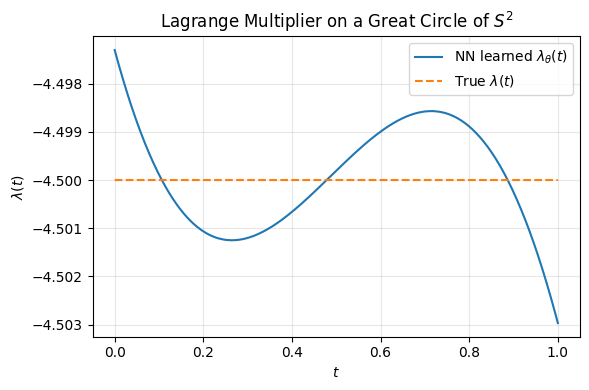

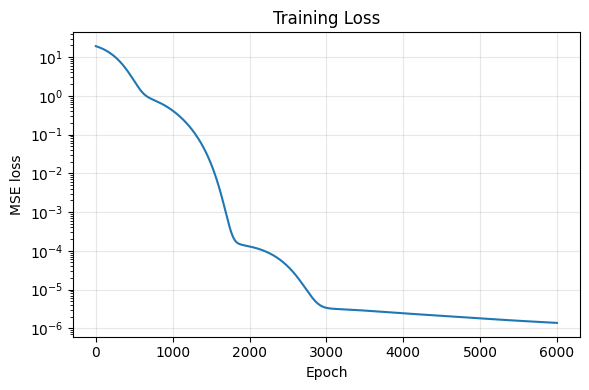

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ============================================================
# Great circle on S^2, acceleration, and Lagrange multiplier
# Constraint: f(q)=||q||^2-1 = 0,  ∇f(q)=2q,  ||∇f||^2 = 4 on S^2
#
# For a constant-speed great circle:
#   γ(t) = (cos(ωt), sin(ωt), 0)
#   γ¨(t) = -ω^2 γ(t)
# Correct multiplier (from q¨ = λ ∇f = 2λ q):
#   λ(t) = (∇f^T q¨)/||∇f||^2 = (2q · q¨)/4 = (q · q¨)/2 = -ω^2/2 (constant)
# ============================================================

np.random.seed(0)
tf.random.set_seed(0)

# ----------------------------
# 1) Parameters and sample times
# ----------------------------
omega = 3.0
N = 200
t = np.linspace(0.0, 1.0, N, dtype=np.float32).reshape(-1, 1)

# ----------------------------
# 2) Great circle γ(t) and γ¨(t)
# ----------------------------
gamma = np.concatenate(
    [np.cos(omega * t), np.sin(omega * t), np.zeros_like(t)],
    axis=1
).astype(np.float32)  # (N,3)

ddot_gamma = (-omega**2 * gamma).astype(np.float32)  # (N,3)

# ----------------------------
# 3) Correct lambda_i
#    ||∇f||^2 = 4 on the unit sphere
#    lambda_i = (∇f^T q¨)/||∇f||^2 = ((2q)^T q¨)/4 = 0.5*(q^T q¨)
# ----------------------------
lambda_true = 0.5 * np.sum(gamma * ddot_gamma, axis=1, keepdims=True).astype(np.float32)

# ----------------------------
# 4) Diagnostics (IMPORTANT)
# ----------------------------
print("Expected lambda =", -omega**2 / 2)
print("lambda_true min/max =", float(lambda_true.min()), float(lambda_true.max()))
print("lambda_true mean/std =", float(lambda_true.mean()), float(lambda_true.std()))
print("max | ||gamma||-1 | =", float(np.max(np.abs(np.linalg.norm(gamma, axis=1) - 1.0))))

# ----------------------------
# 5) Supervised NN: learn lambda(t) from (t_i, lambda_i)
#    Use small model + smaller lr to encourage constant fit
# ----------------------------
model = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(16, activation="swish"),
    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse"
)

history = model.fit(
    t, lambda_true,
    epochs=6000,
    batch_size=32,
    verbose=0
)

# ----------------------------
# 6) Plot lambda(t): true vs learned (FIXED: no axis offset)
# ----------------------------
t_plot = np.linspace(0.0, 1.0, 400, dtype=np.float32).reshape(-1, 1)
lambda_pred = model.predict(t_plot, verbose=0)

# True lambda on dense grid (for plotting)
gamma_plot = np.concatenate(
    [np.cos(omega * t_plot), np.sin(omega * t_plot), np.zeros_like(t_plot)],
    axis=1
).astype(np.float32)
ddot_gamma_plot = (-omega**2 * gamma_plot).astype(np.float32)
lambda_plot_true = 0.5 * np.sum(gamma_plot * ddot_gamma_plot, axis=1, keepdims=True).astype(np.float32)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_plot, lambda_pred, label="NN learned $\\lambda_\\theta(t)$")
ax.plot(t_plot, lambda_plot_true, "--", label="True $\\lambda(t)$")
ax.set_xlabel("$t$")
ax.set_ylabel("$\\lambda(t)$")
ax.set_title("Lagrange Multiplier on a Great Circle of $S^2$")
ax.grid(True, alpha=0.3)
ax.legend()

# Disable Matplotlib offset/scientific formatting so values show as -4.5, etc.
ax.ticklabel_format(axis="y", style="plain", useOffset=False)

plt.tight_layout()
plt.show()

# ----------------------------
# 7) Plot training loss
# ----------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.history["loss"])
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Training Loss")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Next, we change the y-scale to have a bird eye-view of the multiplier.

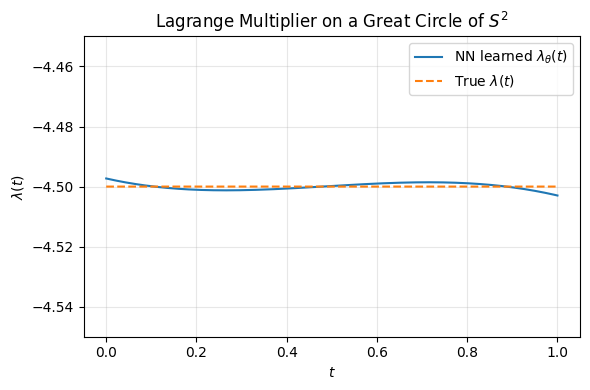

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(t_plot, lambda_pred, label="NN learned $\\lambda_\\theta(t)$")
ax.plot(t_plot, lambda_plot_true, "--", label="True $\\lambda(t)$")

ax.set_xlabel("$t$")
ax.set_ylabel("$\\lambda(t)$")
ax.set_title("Lagrange Multiplier on a Great Circle of $S^2$")

ax.grid(True, alpha=0.3)
ax.legend()

# ---- FIX: explicitly choose a wider y-window ----
ax.set_ylim(-4.55, -4.45)   # adjust as desired

# Disable offset/scientific notation
ax.ticklabel_format(axis="y", style="plain", useOffset=False)

plt.tight_layout()
plt.show()
